<a href="https://colab.research.google.com/github/Saiful-2/telco-customer-churn/blob/main/notebooks/12_telco_feature_importance_and_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom Customer Churn
# Feature Importance and Explainability
# Gaussian Naive Bayes Model

In [1]:
# =========================================
# 1. Import Required Libraries
# =========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =========================================
# 2. Import Explainability Libraries
# =========================================

import shap

from sklearn.inspection import permutation_importance

In [3]:
# =========================================
# 3. Import Final Selected Model
# =========================================

from sklearn.naive_bayes import GaussianNB

In [4]:
# =========================================
# 4. Load Training Dataset
# =========================================

X_train = pd.read_csv(
'https://raw.githubusercontent.com/Saiful-2/datasets/main/X_train_scaled.csv'
)

y_train = pd.read_csv(
'https://raw.githubusercontent.com/Saiful-2/datasets/main/y_train.csv'
)

In [5]:
# =========================================
# 5. Load Testing Dataset
# =========================================

X_test = pd.read_csv(
'https://raw.githubusercontent.com/Saiful-2/datasets/main/X_test_scaled.csv'
)

y_test = pd.read_csv(
'https://raw.githubusercontent.com/Saiful-2/datasets/main/y_test.csv'
)

In [6]:
# =========================================
# 6. Convert Target Variables into Series
# =========================================

y_train = y_train.squeeze()

y_test = y_test.squeeze()

In [7]:
# =========================================
# 7. Train Gaussian Naive Bayes Model
# =========================================

model = GaussianNB()

model.fit(

X_train,

y_train

)

GaussianNB()

In [8]:
# =========================================
# 8. Model Accuracy
# =========================================

model.score(

X_test,

y_test

)

0.7420042643923241

In [9]:
# =========================================
# 9. Permutation Importance
# =========================================

perm_importance = permutation_importance(

model,

X_test,

y_test,

n_repeats=10,

random_state=42

)

In [10]:
# =========================================
# 10. Create Permutation Importance DataFrame
# =========================================

importance_df = pd.DataFrame({

'Feature':X_test.columns,

'Importance':

perm_importance.importances_mean

})

importance_df = importance_df.sort_values(

'Importance',

ascending=False

)

importance_df.head(15)

,Feature,Importance
25,LongTermCustomer,0.008600
19,TenureGroup,0.007321
17,MonthlyCharges,0.006397
20,MonthlyChargesCategory,0.005970
26,HighMonthlyCharges,0.005828
7,InternetService,0.005330
16,PaymentMethod,0.003838
14,Contract,0.003625
15,PaperlessBilling,0.003483
27,PaperlessBillingFlag,0.003483


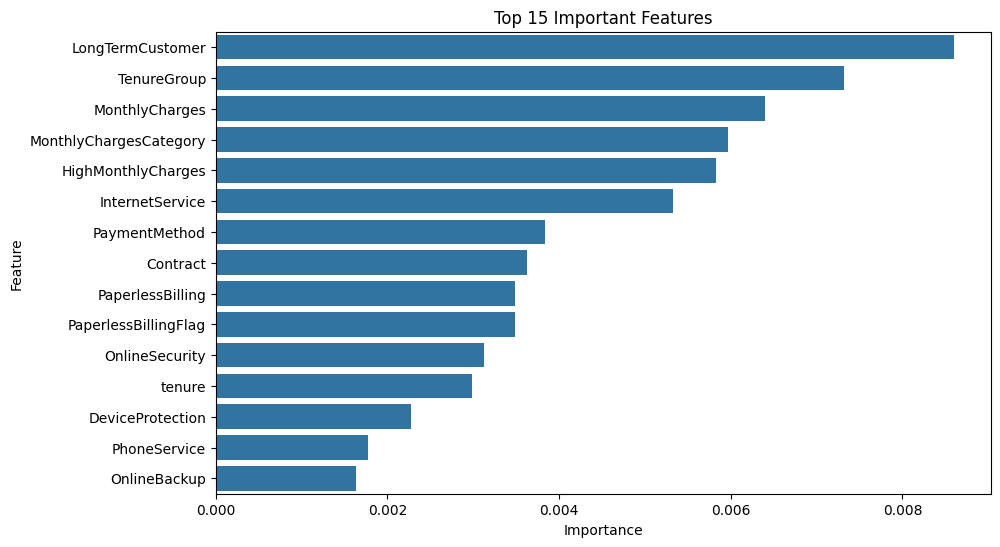

In [11]:
# =========================================
# 11. Top 15 Important Features Plot
# =========================================

plt.figure(figsize=(10,6))

sns.barplot(

data=importance_df.head(15),

x='Importance',

y='Feature'

)

plt.title(

'Top 15 Important Features'

)

plt.show()

In [12]:
# =========================================
# 12. SHAP Explainer
# =========================================

explainer = shap.Explainer(

model.predict,

X_train

)

shap_values = explainer(

X_test

)

PermutationExplainer explainer: 1408it [00:30, 33.44it/s]                          


/tmp/ipykernel_10862/2315071031.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


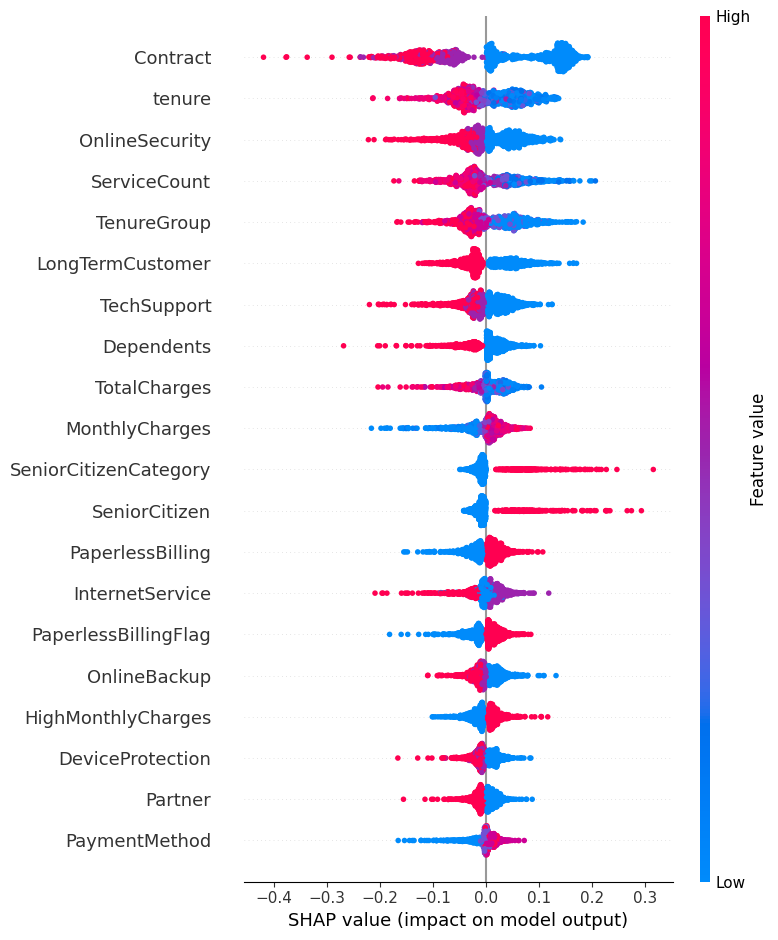

In [13]:
# =========================================
# 13. SHAP Summary Plot
# =========================================

shap.summary_plot(

shap_values,

X_test

)

/tmp/ipykernel_10862/1333221266.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


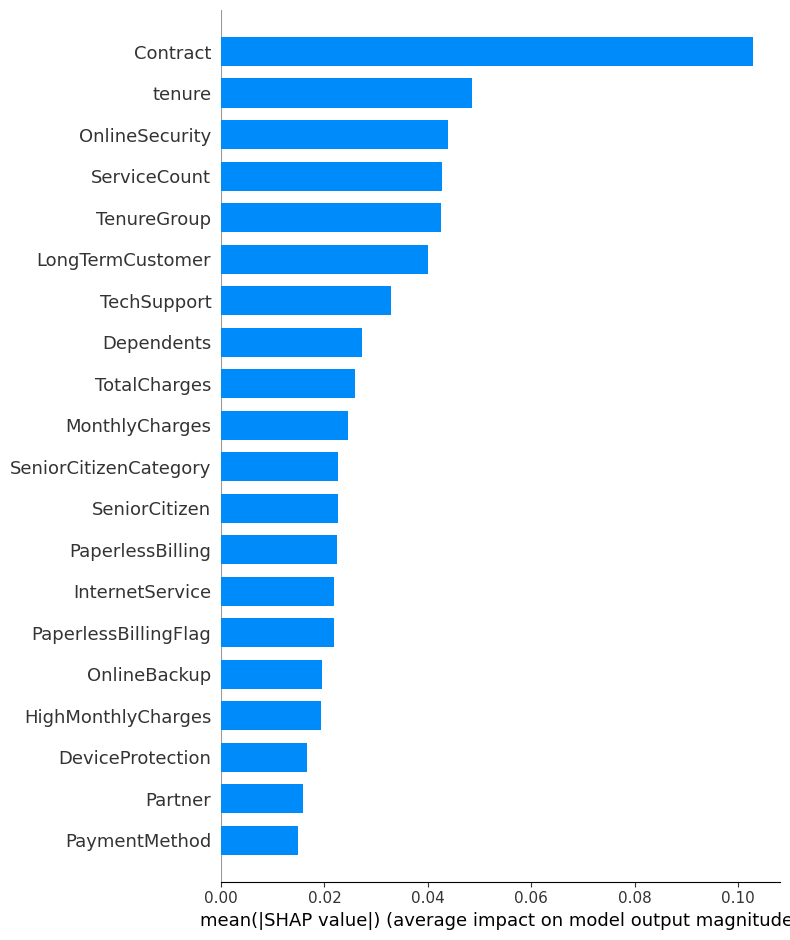

In [14]:
# =========================================
# 14. SHAP Bar Plot
# =========================================

shap.summary_plot(

shap_values,

X_test,

plot_type='bar'

)

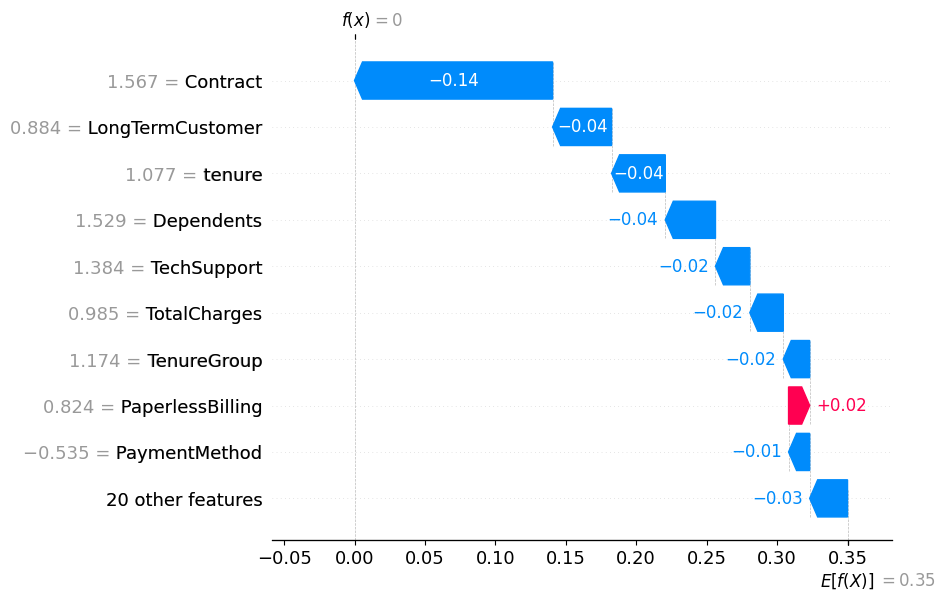

In [15]:
# =========================================
# 15. SHAP Waterfall Plot
# Single Customer Explanation
# =========================================

shap.plots.waterfall(

shap_values[0]

)

In [16]:
# =========================================
# 16. SHAP Force Plot
# =========================================

shap.initjs()

shap.force_plot(

shap_values[0]

)

In [17]:
# =========================================
# 17. Top 10 Important Features
# =========================================

top_features = importance_df.head(10)

top_features

,Feature,Importance
25,LongTermCustomer,0.008600
19,TenureGroup,0.007321
17,MonthlyCharges,0.006397
20,MonthlyChargesCategory,0.005970
26,HighMonthlyCharges,0.005828
7,InternetService,0.005330
16,PaymentMethod,0.003838
14,Contract,0.003625
15,PaperlessBilling,0.003483
27,PaperlessBillingFlag,0.003483


In [18]:
# =========================================
# 18. Business Interpretation
# =========================================

print(

"Most influential features"

" strongly affect customer churn."

)

print(

"These features should receive"

" business attention."

)

Most influential features strongly affect customer churn.
These features should receive business attention.


In [19]:
# =========================================
# 19. Feature Importance Summary
# =========================================

print(

"Permutation Importance completed."

)

print(

"SHAP Explainability completed."

)

Permutation Importance completed.
SHAP Explainability completed.


In [20]:
# =========================================
# 20. Final Conclusion
# =========================================

print(

"Feature importance and"

" explainability completed"

" using Gaussian Naive Bayes."

)

Feature importance and explainability completed using Gaussian Naive Bayes.
